In [3]:
import pandas as pd


In [4]:
df = pd.read_csv("us_disaster_declarations.csv")
df.head()

,fema_declaration_string,disaster_number,state,declaration_type,declaration_date,fy_declared,incident_type,declaration_title,ih_program_declared,ia_program_declared,...,place_code,designated_area,declaration_request_number,last_ia_filing_date,incident_id,region,designated_incident_types,last_refresh,hash,id
0,DR-1-GA,1,GA,DR,1953-05-02T00:00:00Z,1953,Tornado,Tornado,0,1,...,0,Statewide,53013,NaN,53013,4,NaN,2024-08-27T18:22:14Z,413ff808d79f08a6710f6b78f361d5a7de692711,8943dfcf-9786-4e51-8889-d62014034bb2
1,DR-2-TX,2,TX,DR,1953-05-15T00:00:00Z,1953,Tornado,Tornado & Heavy Rainfall,0,1,...,0,Statewide,53003,NaN,53003,6,W,2024-08-27T18:22:14Z,8a8bc885c003cb873c201bb6a3a2771a6d84efb1,ff821327-6b90-4246-b19f-fff8c4b288a8
2,DR-3-LA,3,LA,DR,1953-05-29T00:00:00Z,1953,Flood,Flood,0,1,...,0,Statewide,53005,NaN,53005,6,NaN,2024-08-27T18:22:14Z,b6e6f19ae3c0d2383b7b873b8495bd2770f2ff9a,cd461e08-5ac9-4e70-8507-9c7a3cbff265
3,DR-4-MI,4,MI,DR,1953-06-02T00:00:00Z,1953,Tornado,Tornado,0,1,...,0,Statewide,53004,NaN,53004,5,NaN,2024-08-27T18:22:14Z,34f0061012c8069f145d56a3537cd327b7d4e49b,53be0c04-d2ae-42fb-b070-a01b0a50b7f6
4,DR-5-MT,5,MT,DR,1953-06-06T00:00:00Z,1953,Flood,Floods,0,1,...,0,Statewide,53006,NaN,53006,8,NaN,2024-08-27T18:22:14Z,3bdbec258e4640c3f02971dbc1f9dbc3ebbfc96a,4b3ed0ac-299b-49f0-80d4-9a2a6bacd5a4


In [5]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68485 entries, 0 to 68484
Data columns (total 27 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   fema_declaration_string     68485 non-null  object
 1   disaster_number             68485 non-null  int64 
 2   state                       68485 non-null  object
 3   declaration_type            68485 non-null  object
 4   declaration_date            68485 non-null  object
 5   fy_declared                 68485 non-null  int64 
 6   incident_type               68485 non-null  object
 7   declaration_title           68485 non-null  object
 8   ih_program_declared         68485 non-null  int64 
 9   ia_program_declared         68485 non-null  int64 
 10  pa_program_declared         68485 non-null  int64 
 11  hm_program_declared         68485 non-null  int64 
 12  incident_begin_date         68485 non-null  object
 13  incident_end_date           67963 non-null  ob

In [9]:
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68485 entries, 0 to 68484
Data columns (total 27 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   fema_declaration_string     68485 non-null  object
 1   disaster_number             68485 non-null  int64 
 2   state                       68485 non-null  object
 3   declaration_type            68485 non-null  object
 4   declaration_date            68485 non-null  object
 5   fy_declared                 68485 non-null  int64 
 6   incident_type               68485 non-null  object
 7   declaration_title           68485 non-null  object
 8   ih_program_declared         68485 non-null  int64 
 9   ia_program_declared         68485 non-null  int64 
 10  pa_program_declared         68485 non-null  int64 
 11  hm_program_declared         68485 non-null  int64 
 12  incident_begin_date         68485 non-null  object
 13  incident_end_date           67963 non-null  ob

In [ ]:
# Convert declaration_date to datetime
df['declaration_date'] = pd.to_datetime(df['declaration_date'], errors='coerce')

# Check missing dates
print("Missing Dates:", df['declaration_date'].isnull().sum())

# Extract year and month
df['year'] = df['declaration_date'].dt.year
df['month'] = df['declaration_date'].dt.month

df[['declaration_date','year','month']].head()

In [11]:
df = df.dropna(subset=['declaration_date'])

1️⃣ Yearly Disaster Trend Graph

In [13]:
yearly_counts = df.groupby('year').size().reset_index(name='count')
yearly_counts.head(20)

,year,count
0,1953,13
1,1954,17
2,1955,18
3,1956,16
4,1957,16
5,1958,7
6,1959,7
7,1960,12
8,1961,12
9,1962,22


In [ ]:
It shows the total number of disaster declarations in the US for each year.
There is an overall increasing trend over time, with some years showing sudden spikes.
This may be due to climate change, increase in extreme weather events, better reporting systems, and population growth.

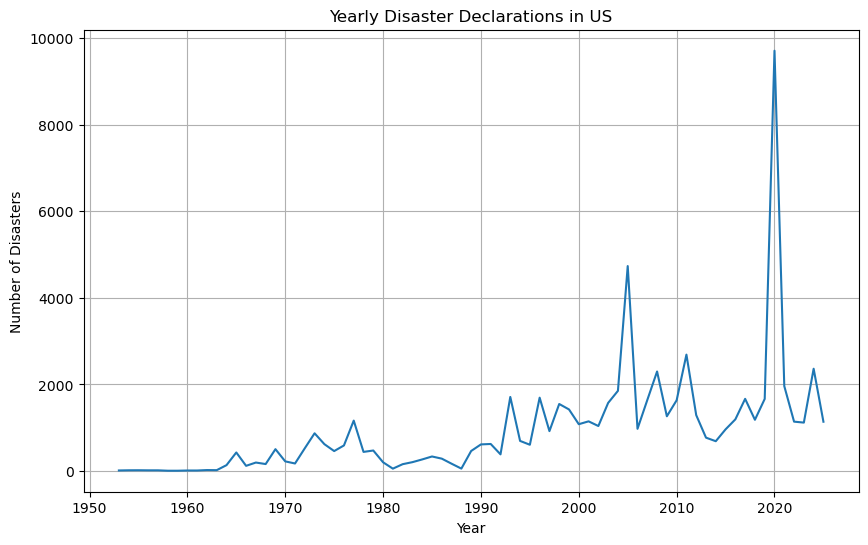

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(yearly_counts['year'], yearly_counts['count'])
plt.title("Yearly Disaster Declarations in US")
plt.xlabel("Year")
plt.ylabel("Number of Disasters")
plt.grid(True)
plt.show()

2️⃣ Disaster Types Over Time (Multi-line Graph)

It shows how different types of disasters (like floods, hurricanes, storms, wildfires) change over the years.Some disaster types occur more frequently than others. Certain types like storms and floods show increasing trends.Climate change, seasonal weather patterns, and geographic conditions may increase specific disaster types

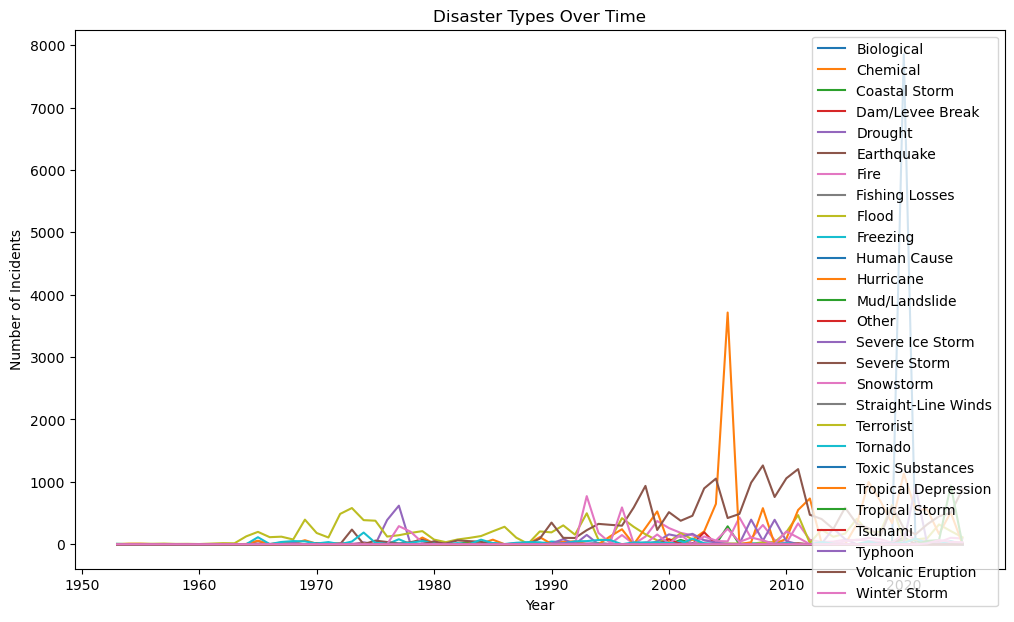

In [17]:
plt.figure(figsize=(12,7))

for col in pivot_data.columns:
    plt.plot(pivot_data.index, pivot_data[col], label=col)

plt.title("Disaster Types Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Incidents")
plt.legend()
plt.show()

 3️⃣ Monthly (Seasonality) Analysis

It shows how disasters are distributed across different months of the year. Some months have more disasters compared to others. Mid-year months often show higher values.
 Hurricane season, monsoon periods, and tornado seasons usually occur during specific months.

In [18]:
monthly_counts = df.groupby('month').size().reset_index(name='count')

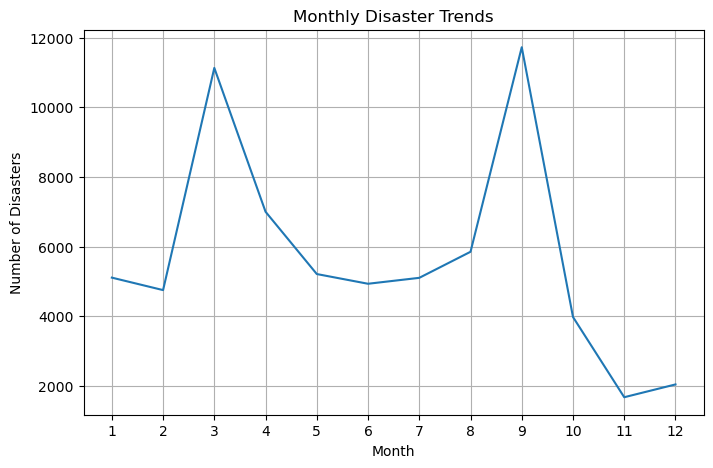

In [19]:
plt.figure(figsize=(8,5))
plt.plot(monthly_counts['month'], monthly_counts['count'])
plt.title("Monthly Disaster Trends")
plt.xlabel("Month")
plt.ylabel("Number of Disasters")
plt.xticks(range(1,13))
plt.grid(True)
plt.show()

4️⃣ Rolling Average Graph


It shows the smoothed trend of disasters over time using a 5-year average. The rolling average shows a steady upward trend without sudden spikes.
 Long-term climate changes and increasing environmental risks may be causing gradual growth in disasters

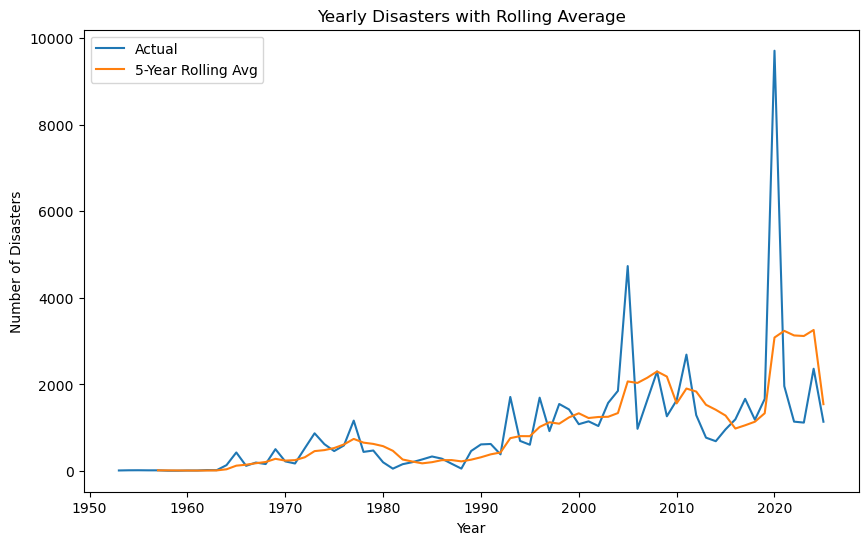

In [20]:
yearly_counts['rolling_avg'] = yearly_counts['count'].rolling(window=5).mean()

plt.figure(figsize=(10,6))
plt.plot(yearly_counts['year'], yearly_counts['count'], label="Actual")
plt.plot(yearly_counts['year'], yearly_counts['rolling_avg'], label="5-Year Rolling Avg")
plt.title("Yearly Disasters with Rolling Average")
plt.xlabel("Year")
plt.ylabel("Number of Disasters")
plt.legend()
plt.show()

5️⃣ Advanced Insights – Alternative Charts

🔷 5.1 Rolling Average → Convert to Area Chart


It shows the smoothed long-term trend of disasters. The area gradually increases over time. Long-term increase in environmental risks and extreme weather.

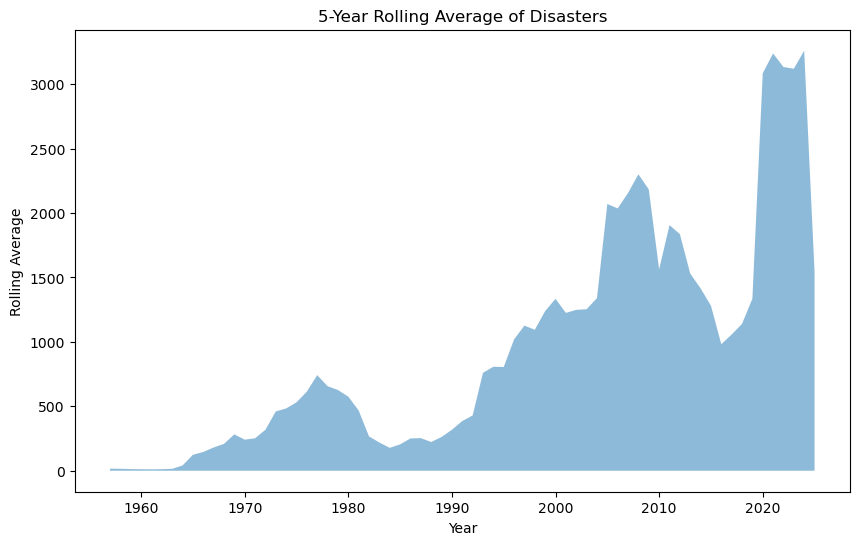

In [23]:
plt.figure(figsize=(10,6))

plt.fill_between(yearly_counts['year'],
                 yearly_counts['rolling_avg'],
                 alpha=0.5)

plt.title("5-Year Rolling Average of Disasters")
plt.xlabel("Year")
plt.ylabel("Rolling Average")
plt.show()

5.2 Growth Rate → Convert to Bar Chart

 
It shows yearly percentage increase or decrease. Some years show strong positive growth, some negative. Major disaster events cause sudden spikes.

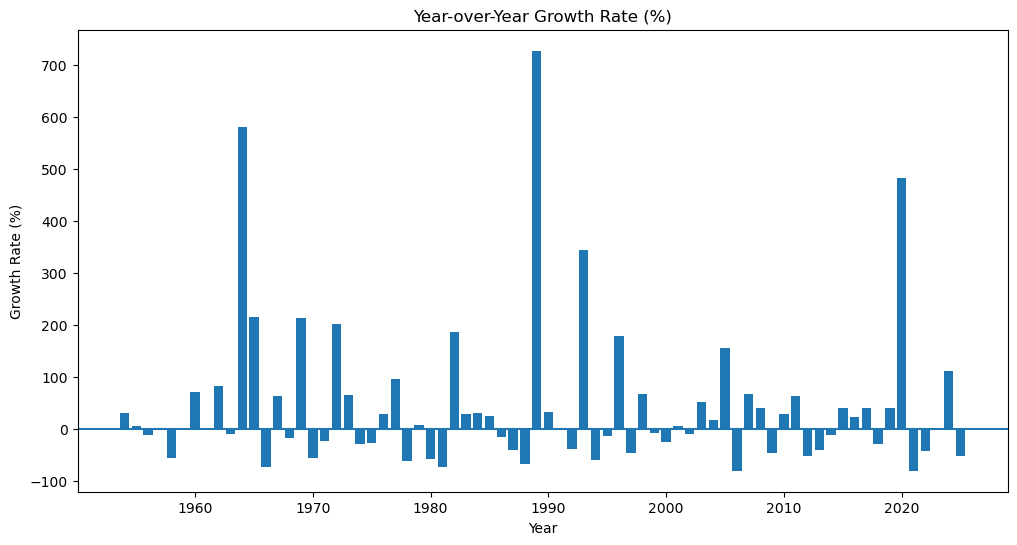

In [24]:
plt.figure(figsize=(12,6))

plt.bar(yearly_counts['year'],
        yearly_counts['growth_rate'])

plt.axhline(0)
plt.title("Year-over-Year Growth Rate (%)")
plt.xlabel("Year")
plt.ylabel("Growth Rate (%)")
plt.show()

5.3 Peak Year → Highlighted Bar Char

It shows total disasters per year and highlights the highest year. One year clearly stands out as the peak. That year likely had major hurricanes or wildfire events.

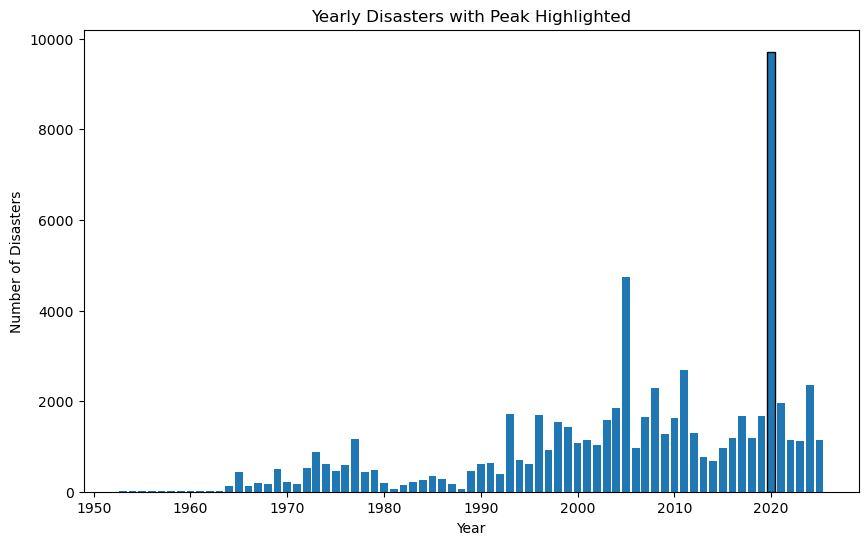

In [25]:
plt.figure(figsize=(10,6))

bars = plt.bar(yearly_counts['year'],
               yearly_counts['count'])

# Highlight peak year
peak_index = yearly_counts['count'].idxmax()
bars[peak_index].set_edgecolor('black')

plt.title("Yearly Disasters with Peak Highlighted")
plt.xlabel("Year")
plt.ylabel("Number of Disasters")
plt.show()

Step:6 Peak Year Analysis

In [22]:
peak_year = yearly_counts.loc[yearly_counts['count'].idxmax()]
print("Peak Disaster Year:")
print(peak_year)

Peak Disaster Year:
year           2020.000000
count          9712.000000
rolling_avg    3084.800000
growth_rate     482.953181
Name: 67, dtype: float64


The temporal analysis shows that disaster declarations have generally increased over time. Certain disaster types dominate, and disasters also show seasonal patterns. The increasing trend may be linked to climate change and improved reporting systems.